In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# LOADING DATA
df = pd.read_csv("../04_distributions/Loan_default.csv")
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


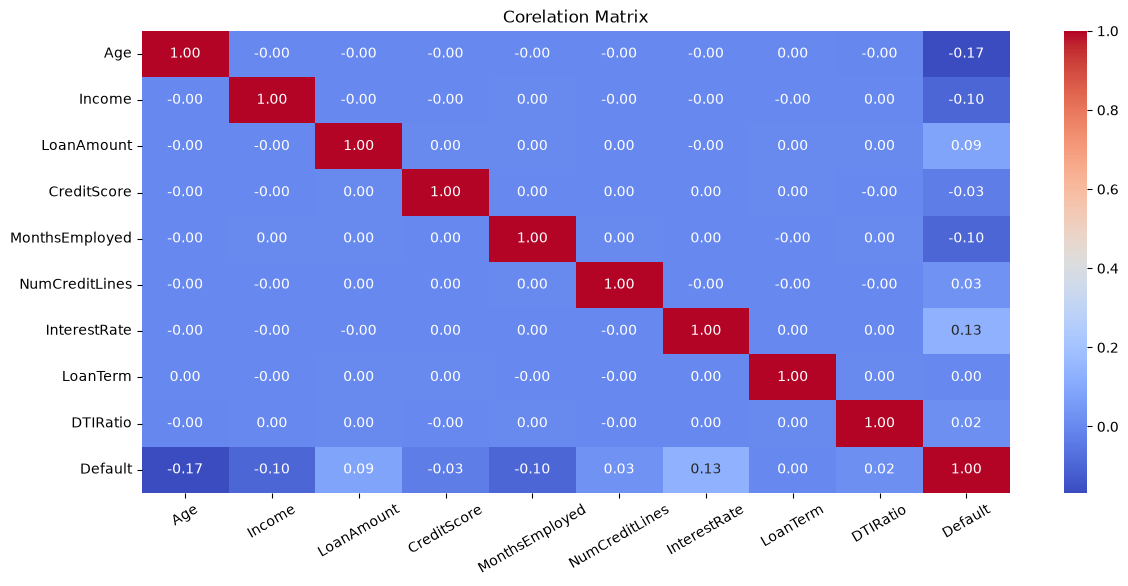

In [58]:
'''
Step 1 — Correlation Matrix
Calculate the correlation matrix for all numeric columns using Pearson, then visualize it as a heatmap using seaborn. This gives you a bird's 
eye view of all relationships in one shot.
'''

# NUMERICAL FEATURES
numeric_features = df.select_dtypes(include='number')

# Corelation
corr_matrix = numeric_features.corr(numeric_only=True)

# HEATMAP
plt.figure(figsize=(14,6))
sns.heatmap(
    corr_matrix,
    annot = True,
    cmap = 'coolwarm',
    fmt = ".2f"
    )
plt.title("Corelation Matrix")    
plt.xticks(rotation=30)    
plt.show()

In [79]:
'''
Step 2 — Spearman Correlation on skewed features
You already know from Topic 04 that Income is uniformly distributed — not normal. Calculate the Spearman correlation between Income and Default, 
and compare it to the Pearson correlation between the same two columns.
Print both values side by side and tell me — do they differ significantly, and what does that tell you?
'''

print("=" * 40)
pearson_corr = df['Income'].corr(df['Default'], method='pearson')
spearman_corr = df["Income"].corr(df['Default'], method="spearman")

print(f'Pearson Corelation: {pearson_corr}')
print(f'Spearman Corelation: {spearman_corr}')
print(" " * 40)

print("=" * 40)
print(f"Differnce between the two: {pearson_corr - spearman_corr}")

Pearson Corelation: -0.09911948445661058
Spearman Corelation: -0.09908694818441109
                                        
Differnce between the two: -3.253627219948485e-05


In [90]:
'''
Step 3 — Covariance
Calculate the covariance between LoanAmount and InterestRate. Then calculate their Pearson corelation. Print both.
Then answer in a comment: the covariance number will look huge — why is it hard to interpret on its own, and how does corelation solve that problem?
'''

print("=" * 40)
print("Corelation and Covariance")
covariance = df['LoanAmount'].cov(df['InterestRate'])
corelation = df['LoanAmount'].corr(df['InterestRate'], method='pearson')
print(" "* 40)
print(f'Covariance: {covariance}\nCorelation: {corelation}')

'''
Covariance tells us when one variable differs from its mean, does the other also differ and in which direction? The problem is it returns
a huge value which can not be interpreted directly. In our case it is -1077; what does this value mean, its very hard to properly interpret. To
solve the interpretability problem; we compute corelation which determines the relation between two variables, their magnitude and direction.
Its output is always between -1 to + 1; -1 means perfect negative corelation; whereas, +1 means perfect positive corelation. Zero, however, tells us
there is no corelation at all. In our case, the covariance is -1077 which is not interpretable; however, if we look at the corelation, it is -0.002291,
which is very close to zero, meaning there is no relationship between these two variables.
'''

Corelation and Covariance
                                        
Covariance: -1077.1245097079877
Corelation: -0.0022911190364665727


'\nCovariance tells us when one variable differs from its mean, does the other also differ and in which direction? The problem is it returns\na huge value which can not be interpreted directly. In our case it is -1077; what does this value mean, its very hard to properly interpret. To\nsolve the interpretability problem; we compute corelation which determines the relation between two variables, their magnitude and direction.\nIts output is always between -1 to + 1; -1 means perfect negative corelation; whereas, +1 means perfect positive corelation. Zero, however, tells us\nthere is no corelation at all. In our case, the covariance is -1077 which is not interpretable; however, if we look at the corelation, it is -0.002291,\nwhich is very close to zero, meaning there is no relationship between these two variables.\n'